## Downscale Temperature Evaluation
Evaluate performance of downscaleTairV1 function with missing SNOTEL days.

In [1]:
%matplotlib ipympl
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from datetime import datetime, date, time
from buildforcing.datasets import PNNLSnotel
import os

In [2]:
site = 'Baldy'
isAlpine = False

In [3]:
# Alpine Environmental Vars
if isAlpine:
    os.environ['SNOTEL_PATH'] = '/projects/ccox1@xsede.org/data/snotel'
    os.environ['NLDAS_PATH'] = '/projects/ccox1@xsede.org/data/nldas'


### Load Data
I only care about the range of data used in the downscaling, so I'll limit the data to that range using the find_usable_dates function from buildforcing.

In [4]:
snotel = PNNLSnotel(site_name=site, storage_path=os.environ['SNOTEL_PATH'])
snotel.load_data()

# print latitude and longitude for reference
print(f"Latitude: {snotel.latitude}, Longitude: {snotel.longitude}")

Latitude: 33.98, Longitude: -109.5


In [5]:
start_date, end_date = snotel.find_usable_dates()
print(f"Usable dates: {start_date} to {end_date}")

Usable dates: 1988-09-27 to 2021-09-30


In [6]:
# Extract SNOTEL data for the usable date range or starting in 1990, whichever is later
if start_date < date(1990, 1, 1):
    start_date = date(1990, 1, 1)

snotel_data = snotel.data[start_date.strftime('%Y-%m-%d'):end_date.strftime('%Y-%m-%d')]

In [7]:
# Ensure dataset is complete
snotel_data = snotel_data.asfreq('D')

#### Visualization

In [8]:
# Calculate F temperatures for easier analysis
snotel_data['T_max_F'] = snotel_data['T_max_C'] * 9/5 + 32
snotel_data['T_min_F'] = snotel_data['T_min_C'] * 9/5 + 32
snotel_data['T_avg_F'] = snotel_data['T_avg_C'] * 9/5 + 32

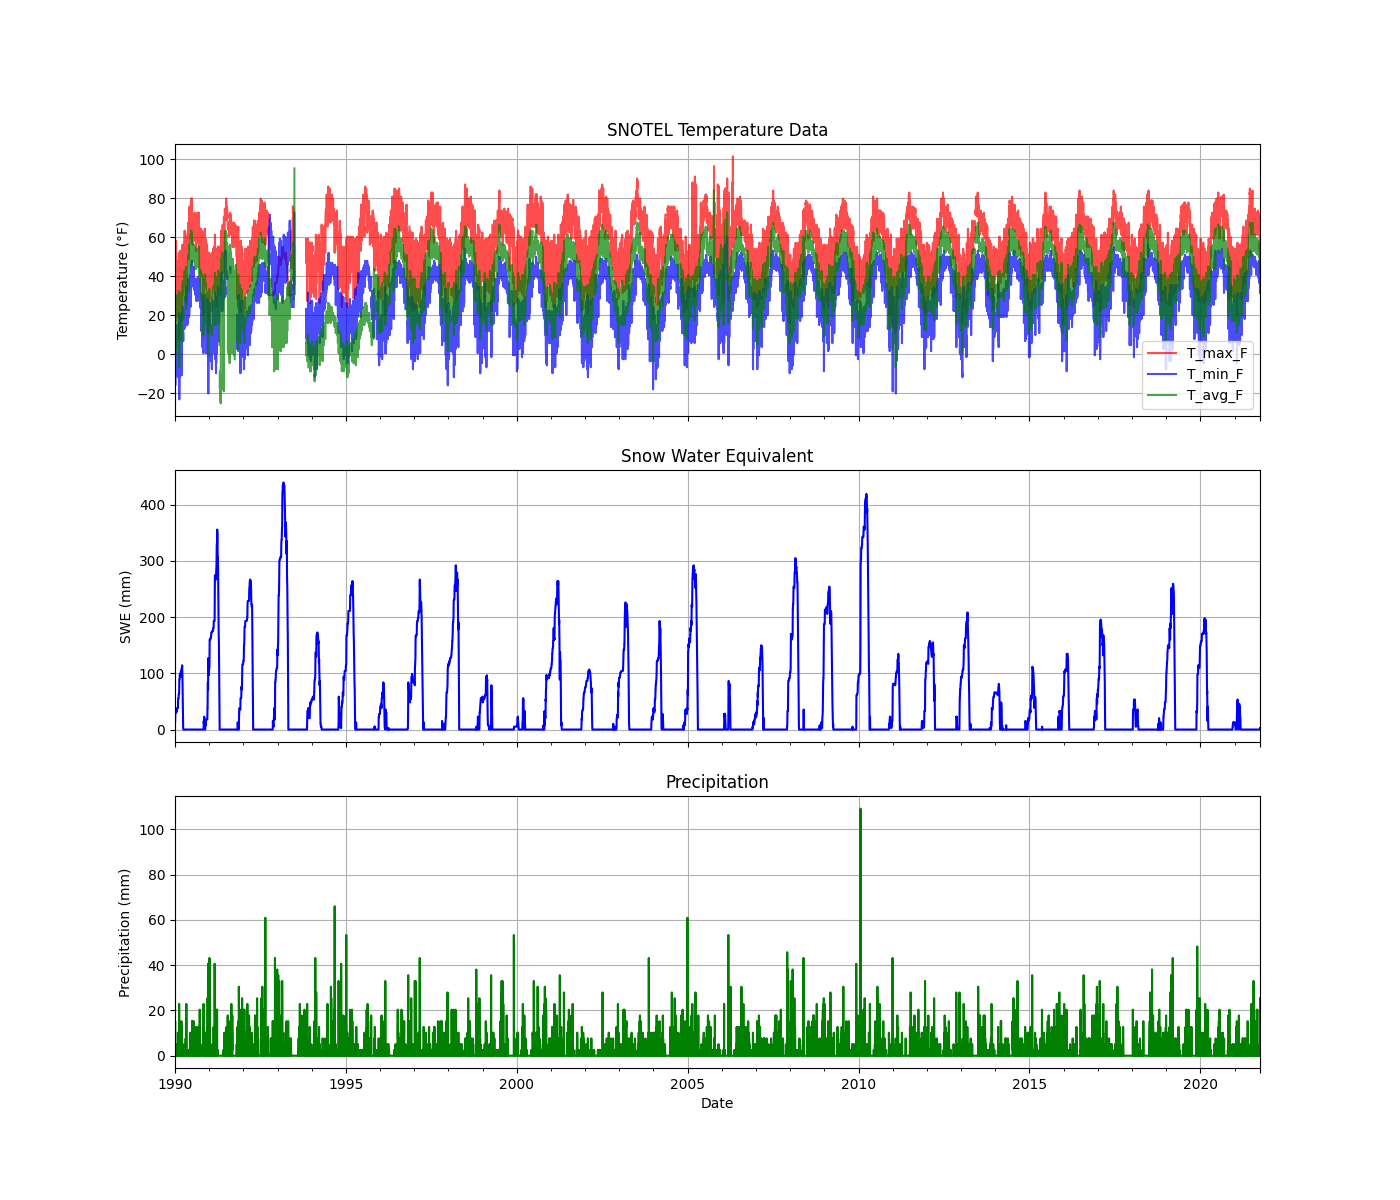

In [9]:
# Create a single figure with 3 subplots (temperature, SWE, precipitation)
fig, (ax1, ax2, ax3) = plt.subplots(3, 1, figsize=(14, 12), sharex=True)

# Plot temperatures in the top subplot
snotel_data['T_max_F'].plot(ax=ax1, label='T_max_F', color='red', alpha=0.7)
snotel_data['T_min_F'].plot(ax=ax1, label='T_min_F', color='blue', alpha=0.7)
snotel_data['T_avg_F'].plot(ax=ax1, label='T_avg_F', color='green', alpha=0.7)
ax1.set_ylabel('Temperature (°F)')
ax1.set_title('SNOTEL Temperature Data')
ax1.legend()
ax1.grid(True)

# Plot SWE in the middle subplot
ax2.plot(snotel_data.index, snotel_data['swe_mm'], color='blue')
ax2.set_ylabel('SWE (mm)')
ax2.set_title('Snow Water Equivalent')
ax2.grid(True)

# Plot Precipitation in the bottom subplot
ax3.plot(snotel_data.index, snotel_data['precip_mm'], color='green')
ax3.set_xlabel('Date')
ax3.set_ylabel('Precipitation (mm)')
ax3.set_title('Precipitation')
ax3.grid(True)

plt.show()

## Downscale Testing

Extract sections of interest for manual review.

In [19]:
test_start = '2004-01-01'
test_end = '2007-12-31'

In [11]:
from buildforcing.downscale import downscaleTairV1
from buildforcing.datasets import siteNLDAS

In [20]:
nldas_data = siteNLDAS(snotel.latitude, snotel.longitude, start_date=datetime.strptime(test_start, '%Y-%m-%d'), end_date=datetime.strptime(test_end, '%Y-%m-%d'))
nldas_data.loadNetCDF(os.environ['NLDAS_PATH'])

In [13]:
nldas_data.data.tail()

,LWdown,PSurf,Qair,Rainf,SWdown,Tair,Wind_E,Wind_N
Date&Time,,,,,,,,
2006-12-30 20:00:00+00:00,199.45,72355.3,0.003169,0.000,517.782,269.74,1.41,-5.47
2006-12-30 21:00:00+00:00,194.05,72333.0,0.003209,0.180,484.784,270.45,2.76,-5.15
2006-12-30 22:00:00+00:00,194.03,72413.1,0.003006,0.000,362.880,269.74,2.43,-5.23
2006-12-30 23:00:00+00:00,194.02,72493.1,0.002804,0.236,216.312,269.03,2.09,-5.31
2006-12-31 00:00:00+00:00,173.49,72572.9,0.002602,0.000,27.844,268.33,1.76,-5.39


In [21]:
nldas_Tair_downscaled = downscaleTairV1(nldas_data.data['Tair'], snotel_data.loc[test_start:test_end,'T_max_C'], snotel_data.loc[test_start:test_end,'T_min_C'])

In [22]:
# Remove snotel timezone for comparison
snotel_data_notz = snotel_data[test_start:test_end].tz_convert(nldas_data.data.index.tz)
snotel_data_notz.index

DatetimeIndex(['2004-01-01 07:00:00+00:00', '2004-01-02 07:00:00+00:00',
               '2004-01-03 07:00:00+00:00', '2004-01-04 07:00:00+00:00',
               '2004-01-05 07:00:00+00:00', '2004-01-06 07:00:00+00:00',
               '2004-01-07 07:00:00+00:00', '2004-01-08 07:00:00+00:00',
               '2004-01-09 07:00:00+00:00', '2004-01-10 07:00:00+00:00',
               ...
               '2007-12-22 07:00:00+00:00', '2007-12-23 07:00:00+00:00',
               '2007-12-24 07:00:00+00:00', '2007-12-25 07:00:00+00:00',
               '2007-12-26 07:00:00+00:00', '2007-12-27 07:00:00+00:00',
               '2007-12-28 07:00:00+00:00', '2007-12-29 07:00:00+00:00',
               '2007-12-30 07:00:00+00:00', '2007-12-31 07:00:00+00:00'],
              dtype='datetime64[ns, UTC]', name='Date', length=1461, freq='D')

In [16]:
nldas_Tair_downscaled.index

DatetimeIndex(['2005-01-01 00:00:00+00:00', '2005-01-01 01:00:00+00:00',
               '2005-01-01 02:00:00+00:00', '2005-01-01 03:00:00+00:00',
               '2005-01-01 04:00:00+00:00', '2005-01-01 05:00:00+00:00',
               '2005-01-01 06:00:00+00:00', '2005-01-01 07:00:00+00:00',
               '2005-01-01 08:00:00+00:00', '2005-01-01 09:00:00+00:00',
               ...
               '2006-12-30 15:00:00+00:00', '2006-12-30 16:00:00+00:00',
               '2006-12-30 17:00:00+00:00', '2006-12-30 18:00:00+00:00',
               '2006-12-30 19:00:00+00:00', '2006-12-30 20:00:00+00:00',
               '2006-12-30 21:00:00+00:00', '2006-12-30 22:00:00+00:00',
               '2006-12-30 23:00:00+00:00', '2006-12-31 00:00:00+00:00'],
              dtype='datetime64[ns, UTC]', name='Date&Time', length=17497, freq=None)

In [23]:
# Convert nldas to C for comparison
nldas_data_Tair_C = nldas_data.data['Tair'] - 273.15
nldas_Tair_downscaled_C = nldas_Tair_downscaled - 273.15

<Axes: title={'center': 'SNOTEL Temperature Data (C)'}, xlabel='Date&Time'>

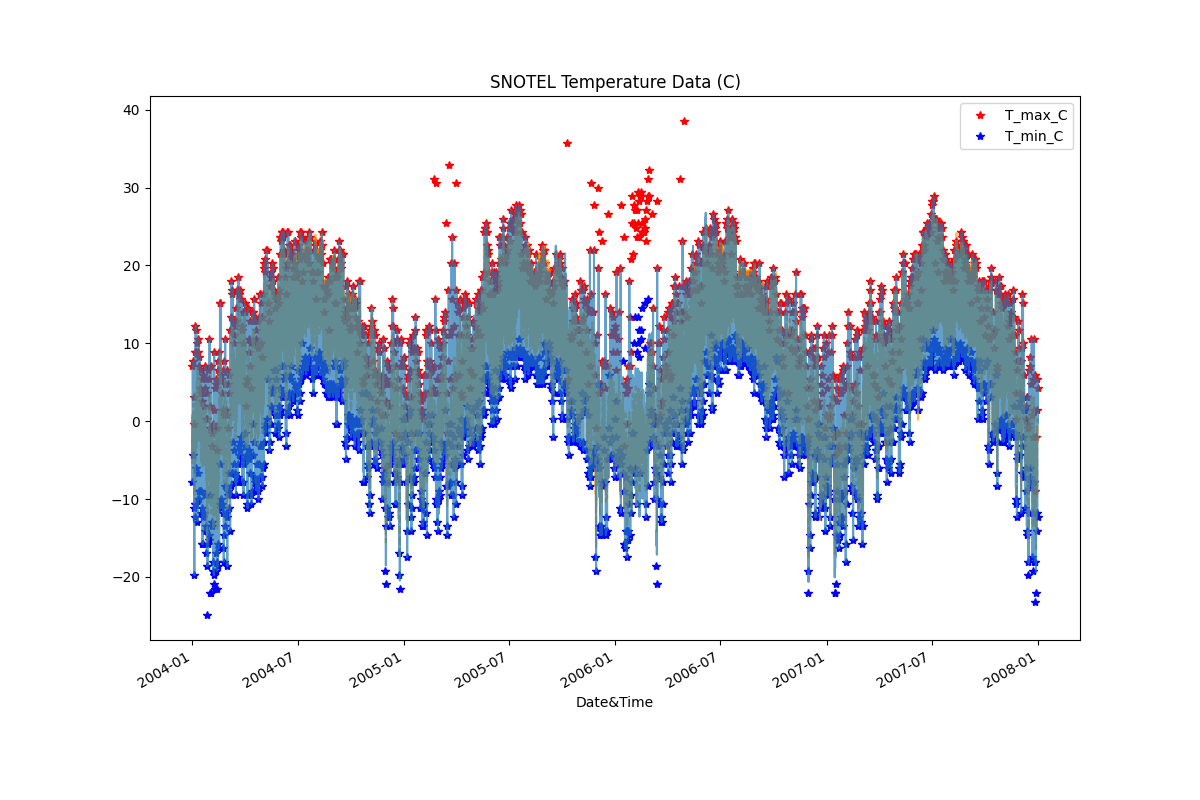

In [24]:
# Plot snotel data and downscaled data for comparison
fig, ax = plt.subplots(1,1, figsize=(12, 8))
snotel_data_notz[['T_max_C', 'T_min_C']].plot(title='SNOTEL Temperature Data (C)', style=['r*', 'b*'], ax=ax)

nldas_data_Tair_C.plot(label='Raw NLDAS Tair (C)', color='orange', linestyle='--', alpha=0.7)
nldas_Tair_downscaled_C.plot(label='Downscaled NLDAS Tair (C)', alpha=0.7)
